In [1]:
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
import sparrow as sp
from sparrow.io._visium_hd import visium_hd
from napari_spatialdata import Interactive
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import _rasterize_bins from ../scripts/utils
import sys
sys.path.append('../scripts')
from utils import _rasterize_bins


/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribut

In this notebook, we are going to preprocess the 8um bin size according to the single-cell analysis pipeline.

In [2]:
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.n_jobs = 8
sc.settings.verbosity = 3

In [3]:
sdata = sd.read_zarr('../data/Visium_HD_Liver/Visium_HD_Liver_zarr')

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:

## Cell type scoring

Predicted proportions when using the entire atlas.

In [4]:
# Get cell type proportions of the cells
sdata.tables['square_008um_atlas_celltype_scores'].obs['annotation'].value_counts(normalize=True)

annotation
Hepatocytes                          0.943352
Kupffercells                         0.014154
Cholangiocytes                       0.008890
Stromalcells                         0.007912
Endothelialcells                     0.005854
Bcells                               0.002928
MonocytesandMonocytesderivedcells    0.002921
HsPCs                                0.002666
cDC1s                                0.001838
MigcDCs                              0.001660
NKcells                              0.001584
Tcells                               0.001493
Neutrophils                          0.001250
cDC2s                                0.001023
ILC1s                                0.000993
pDCs                                 0.000941
Basophils                            0.000542
Name: proportion, dtype: float64

Predicted proportions when filtering the score of the marker genes (see `5_1_process_marker_genes.ipynb`).

In [3]:
# Get cell type proportions of the cells
sdata.tables['square_008um_atlas_filtered1e-2_celltype_scores'].obs['annotation'].value_counts(normalize=True)

annotation
Hepatocytes                          0.878861
MonocytesandMonocytesderivedcells    0.015844
Kupffercells                         0.015428
cDC2s                                0.013330
cDC1s                                0.011235
Bcells                               0.008929
NKcells                              0.008216
HsPCs                                0.007102
Tcells                               0.006272
Stromalcells                         0.005572
Endothelialcells                     0.005173
ILC1s                                0.005037
MigcDCs                              0.004696
Neutrophils                          0.004473
Cholangiocytes                       0.004282
Basophils                            0.002826
pDCs                                 0.002724
Name: proportion, dtype: float64

Predicted proportions when only using top 10% of marker genes (based on score).

In [5]:
# Get cell type proportions of the cells
sdata.tables['square_008um_atlas_q90_celltype_scores'].obs['annotation'].value_counts(normalize=True)

annotation
Hepatocytes                          0.939421
Bcells                               0.006627
Kupffercells                         0.004874
Cholangiocytes                       0.004770
Tcells                               0.004768
MonocytesandMonocytesderivedcells    0.004217
cDC1s                                0.004187
Stromalcells                         0.003647
pDCs                                 0.003522
NKcells                              0.003498
HsPCs                                0.003448
MigcDCs                              0.003376
cDC2s                                0.002943
Endothelialcells                     0.002893
ILC1s                                0.002891
Neutrophils                          0.002549
Basophils                            0.002369
Name: proportion, dtype: float64

/tmp/ipykernel_127616/1033745083.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdata.tables[table_layer]


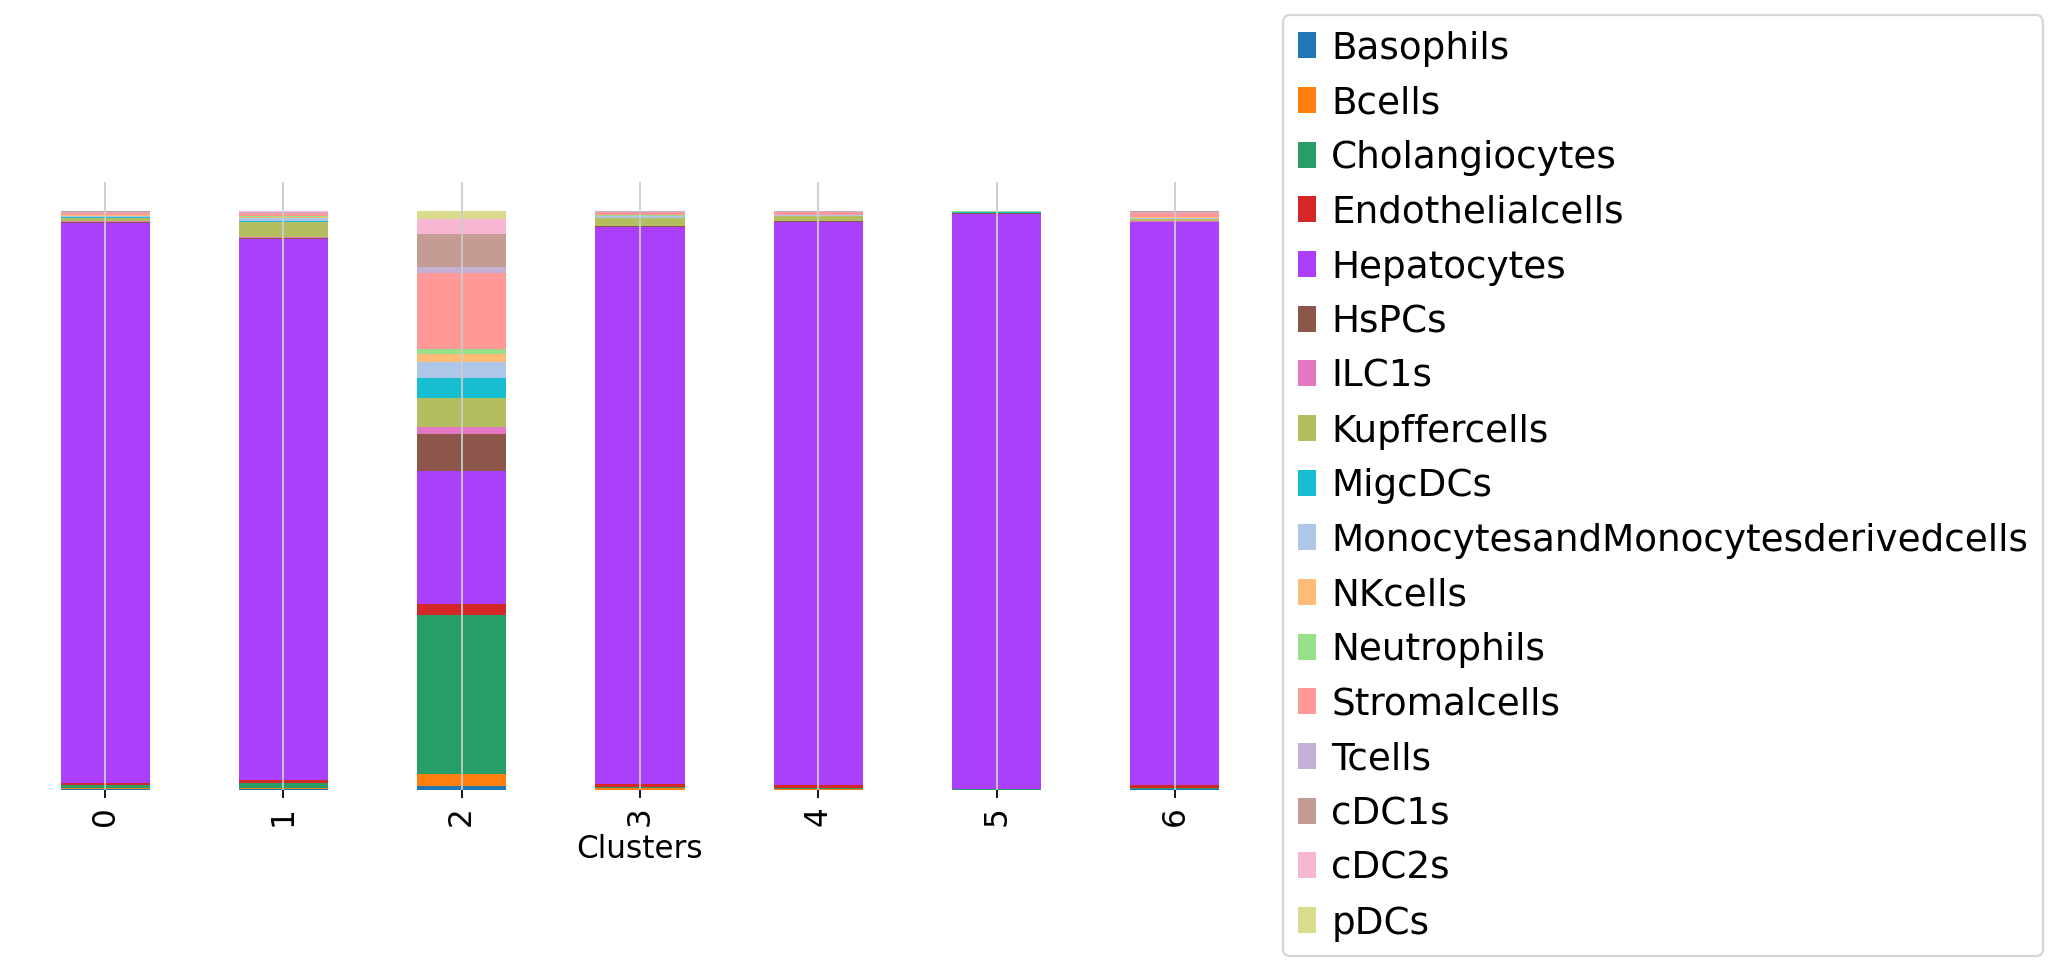

In [7]:
celltype_column = "annotation"
table_layer = "square_008um_atlas_celltype_scores"
stacked = (
        sdata.tables[table_layer]
        .obs.groupby(["clusters", celltype_column], as_index=False)
        .size()
        .pivot(index="clusters", columns=celltype_column)
        .fillna(0)
    )
stacked_norm = stacked.div(stacked.sum(axis=1), axis=0)
stacked_norm.columns = list(sdata.tables[table_layer].obs[celltype_column].cat.categories)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

stacked_norm.plot(kind="bar", stacked=True, ax=fig.gca())
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.get_yaxis().set_ticks([])
plt.xlabel("Clusters")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize="large")

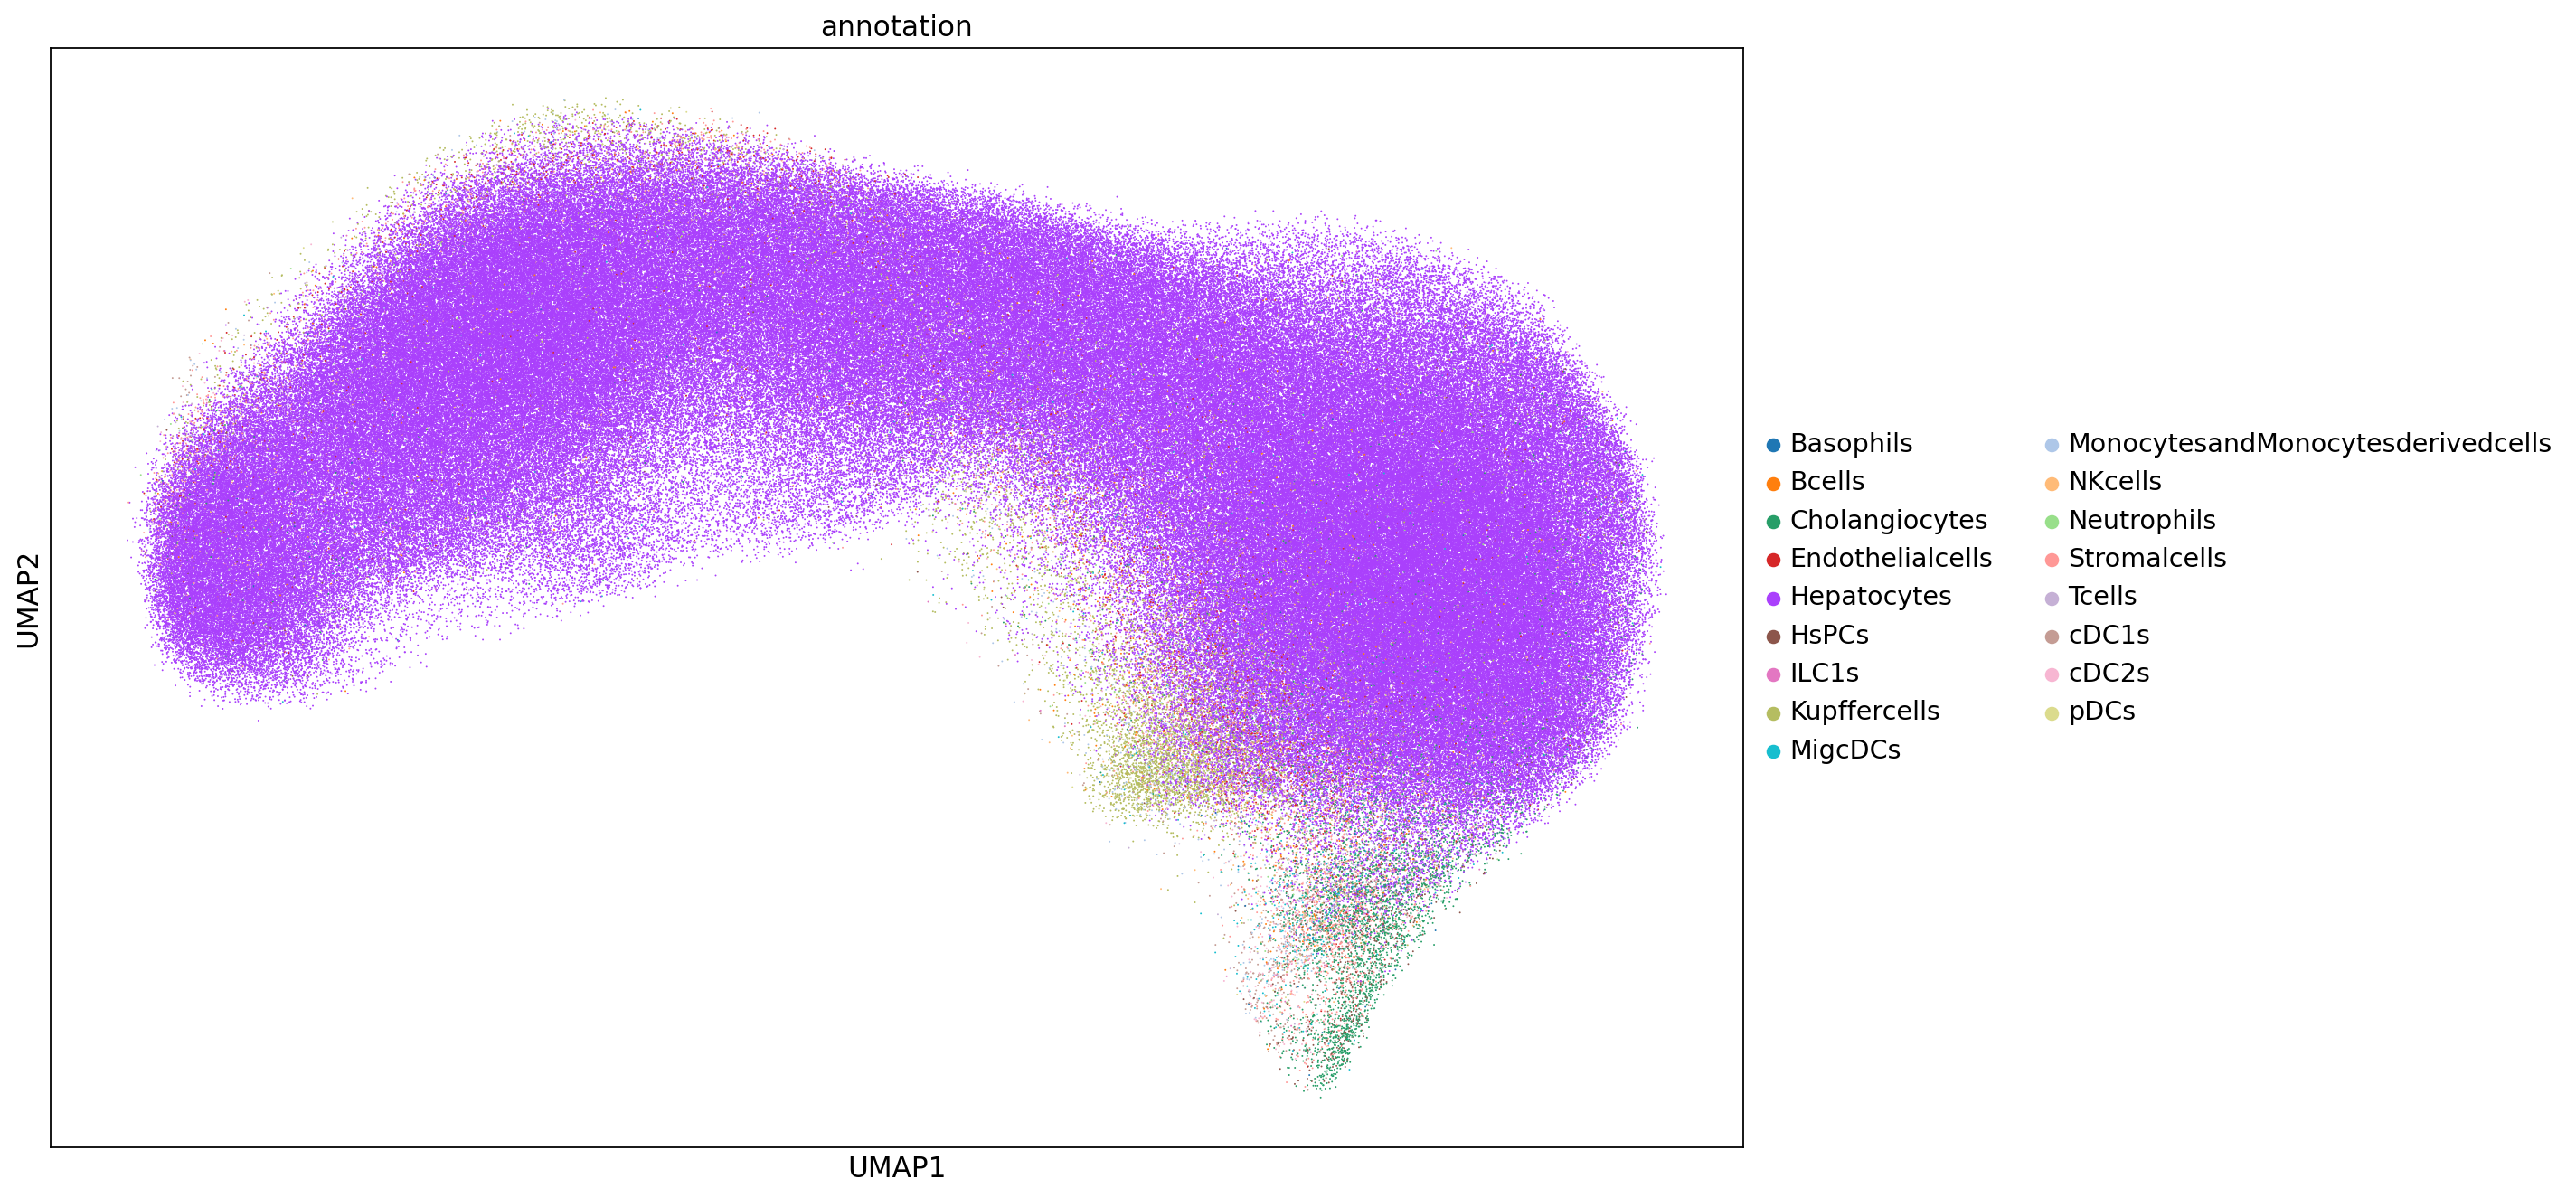

(-5.224588179588318,
 15.193105959892273,
 2.3787771344184874,
 13.830948483943938)

In [8]:
# UMAP plot with cells colored by cell type.
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
sc.pl.umap(
    sdata.tables[table_layer],
    color=[celltype_column],
    ax=ax,
    size=3,
)
ax.axis("off")


<Axes: xlabel='Cleanliness', ylabel='annotation'>

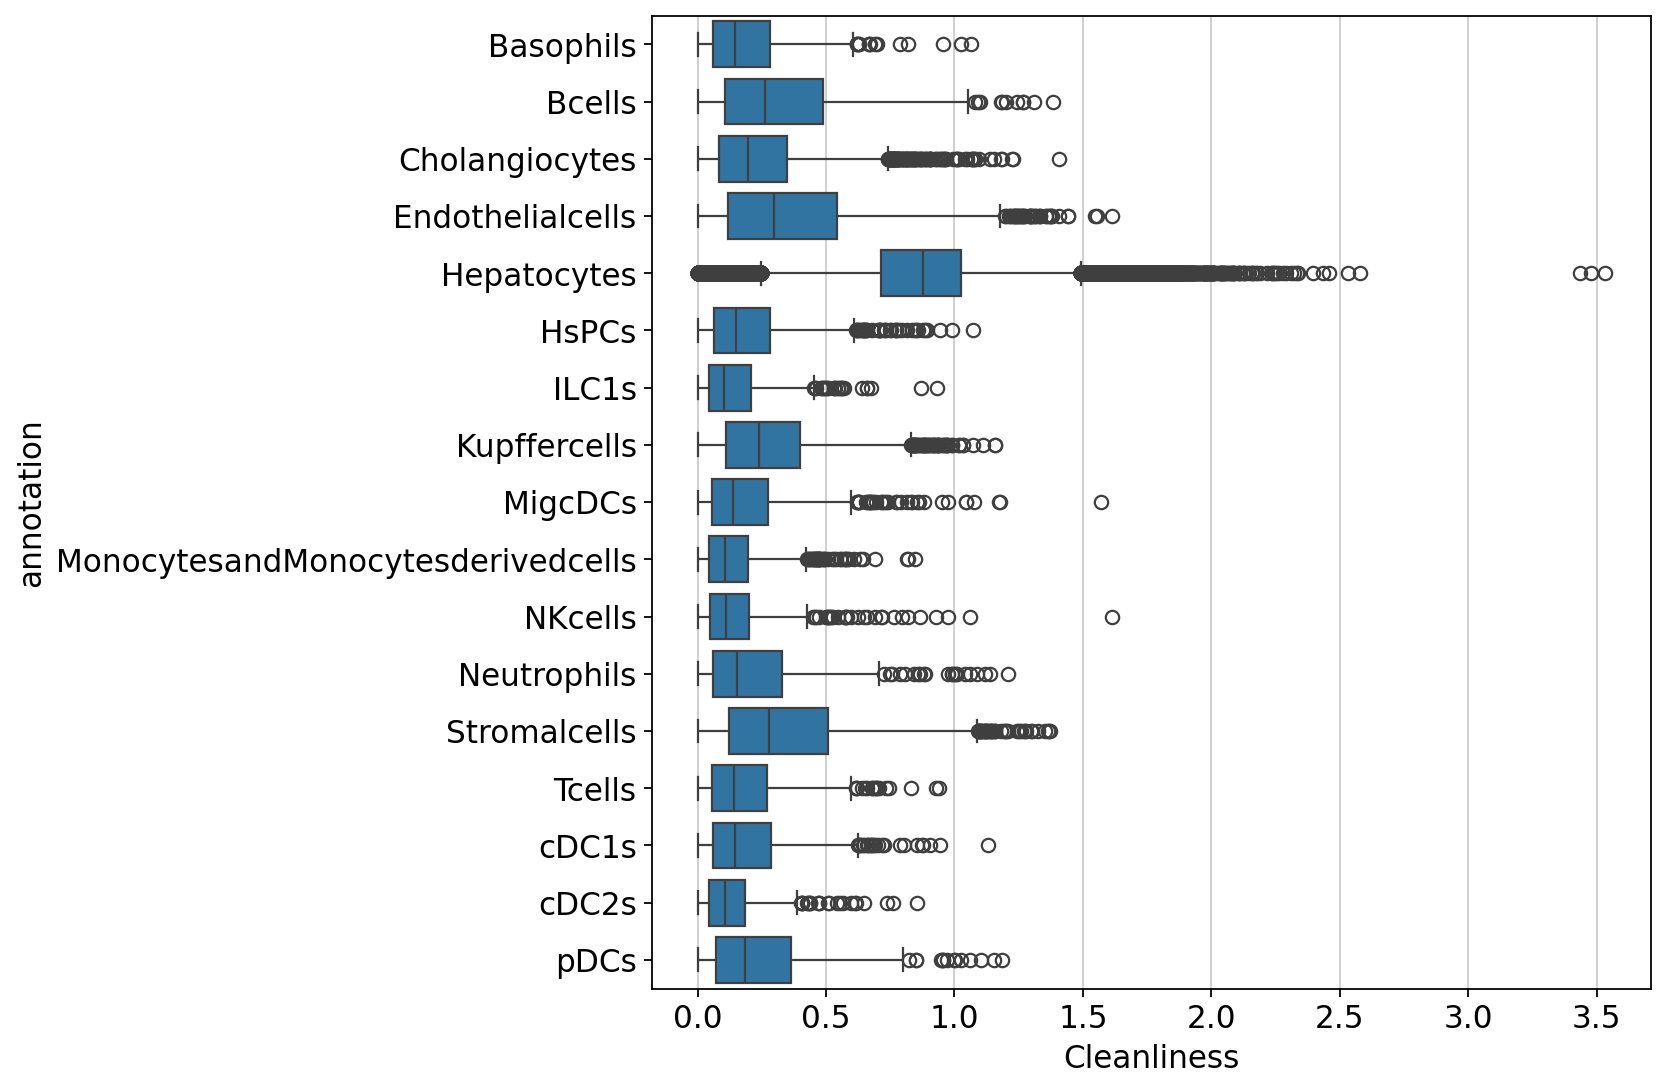

: 

In [ ]:
sns.boxplot(y="annotation", x="Cleanliness",
            data=sdata[table_layer].obs[(sdata[table_layer].obs["Cleanliness"] < 5) & 
                                        (sdata[table_layer].obs["Cleanliness"] > 0)])
            #data=sdata[table_layer].obs)